# Example Notebook

In [1]:
## Import libraries
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import sys
import os

sys.path.append(os.getcwd())
from utils import load_grid_vertex, plot_map2d, read_variables, read_compound_name


In [2]:

data_root='/scratch/yanchun/cmorout'
model = 'DUMMY-MODEL'
experiment='piControl'
variant='r1i1p1f1'
version='v20260601'


In [ ]:
# data path
data_path = os.path.join(data_root, model, experiment, version)

# load grid
grid_file = '~/tools/data/tnx1v4/grid.nc'
lat, lon, clat, clon = load_grid_vertex(grid_file)
with xr.open_dataset(grid_file) as ds:
    pmask = ds['pmask'].values
    parea = ds['parea'].values

# load methods for plotting
vars =read_variables('data/methods.txt')
#print(vars['ocean.masscello.tavg-ol-hxy-sea.mon.glb'])

{'vertical': 'sum', 'timeseries': 'sum'}


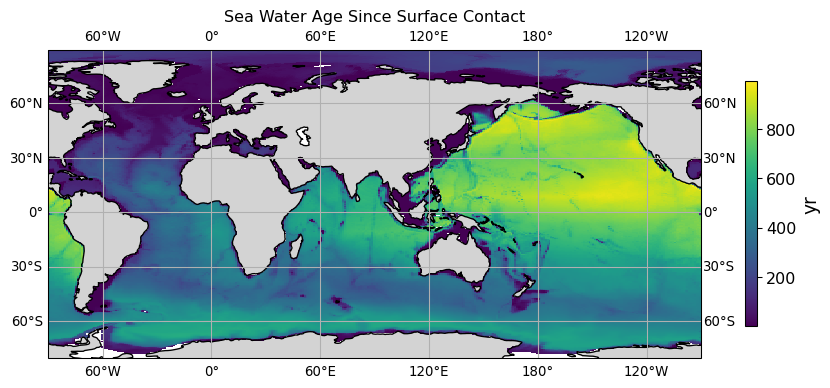

agessc: [1.97607355e+12 1.97611848e+12 1.97618927e+12 1.97584798e+12
 1.97518527e+12 1.97474675e+12 1.97470651e+12 1.97484076e+12
 1.97494091e+12 1.97509474e+12 1.97582400e+12 1.97640182e+12]


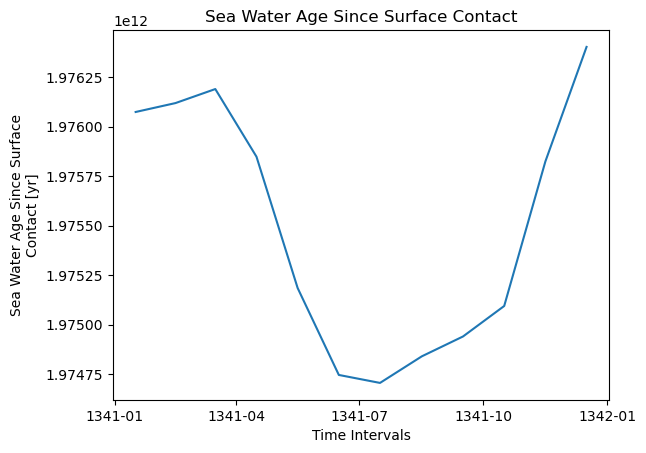

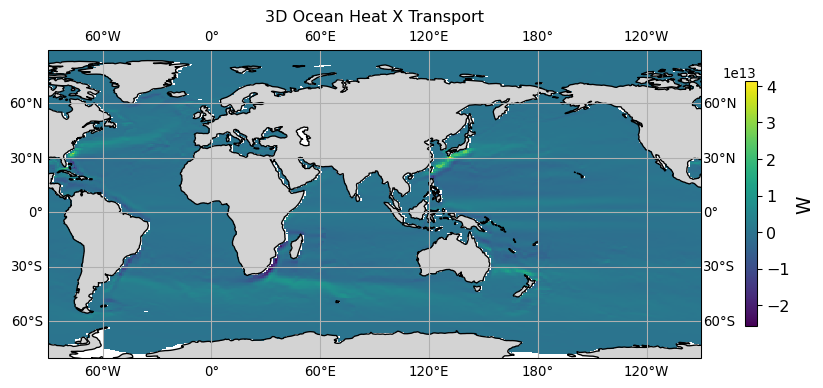

hfx: [3.08358519e+20 3.84610327e+20 3.85589399e+20 4.21432281e+20
 6.00531909e+20 6.22260701e+20 5.63309890e+20 3.40283637e+20
 3.30852233e+20 2.15620772e+20 3.28725999e+20 3.67621931e+20]


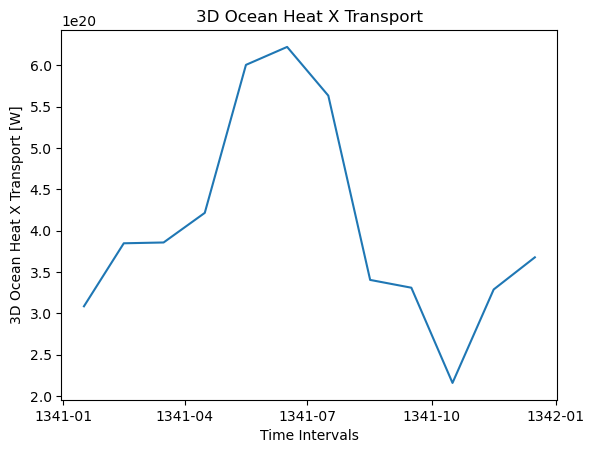

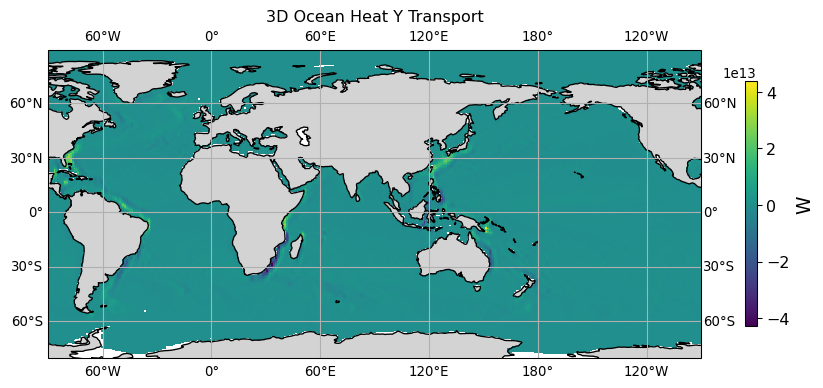

hfy: [ 4.16667212e+20  4.42605197e+20  3.33712279e+20  2.93898574e+20
  2.30240917e+20  5.51123896e+19  2.86157137e+19 -8.42055654e+19
 -4.94407647e+19 -4.96224281e+19  1.72142326e+20  3.35967794e+20]


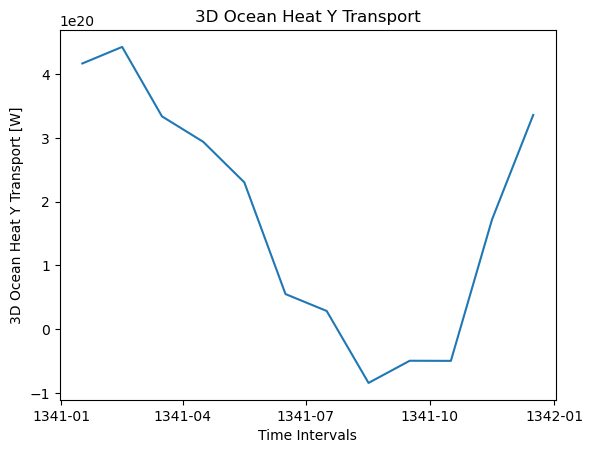

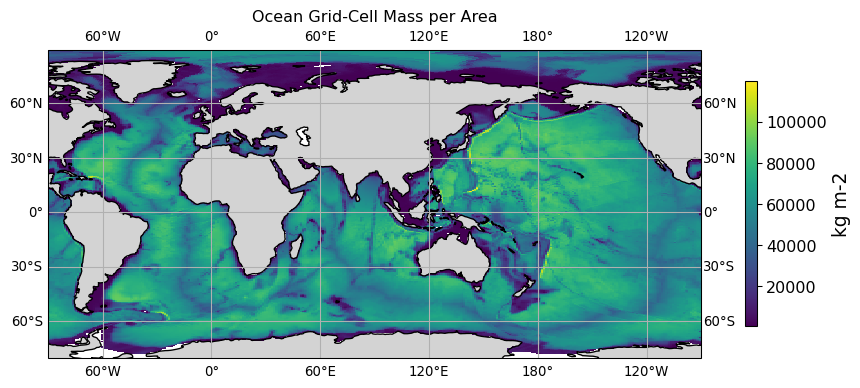

masscello: [2.28076615e+14 2.28076617e+14 2.28076616e+14 2.28076615e+14
 2.28076615e+14 2.28076616e+14 2.28076616e+14 2.28076616e+14
 2.28076617e+14 2.28076617e+14 2.28076617e+14 2.28076617e+14]


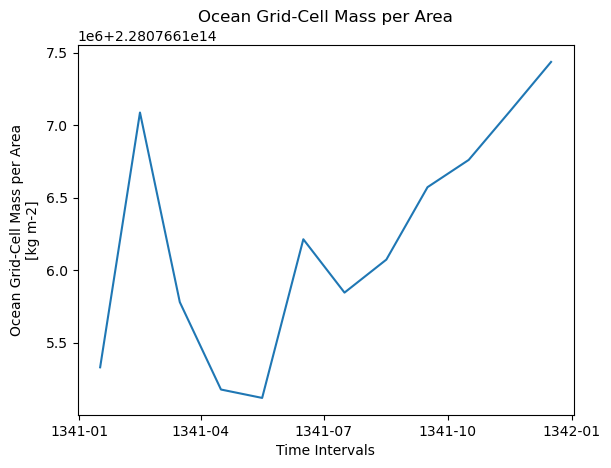

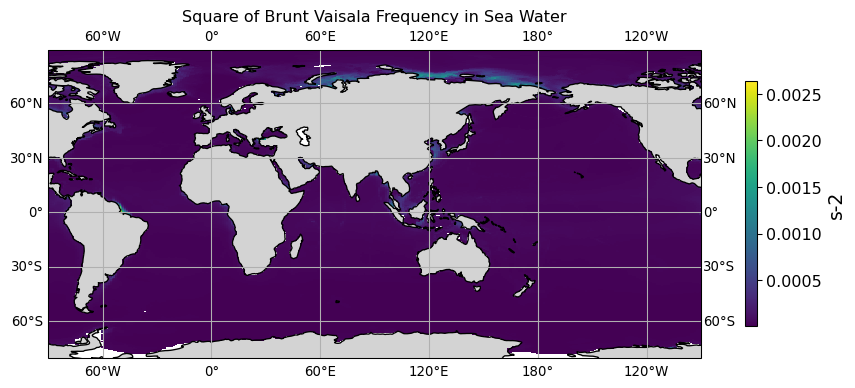

obvfsq: [173466.18088811 173364.3934562  172986.69115251 180018.76760804
 196244.98302518 236014.97061209 253043.26111264 237601.05173424
 206414.66401687 180400.57035507 171035.08447481 171994.7355977 ]


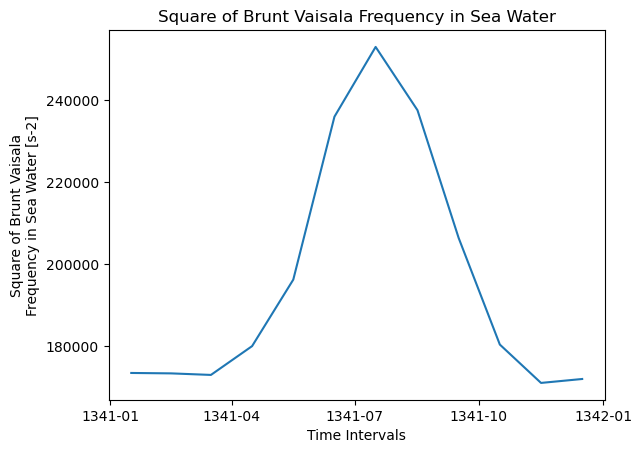

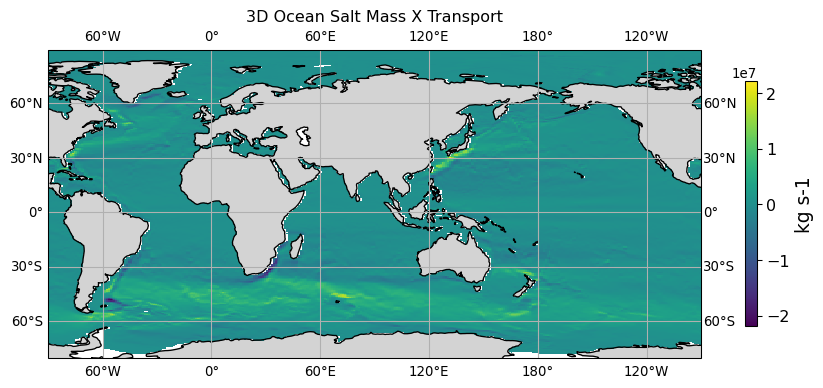

sfx: [1.40899543e+15 1.49136456e+15 1.39951397e+15 1.44683129e+15
 1.60555796e+15 1.60496002e+15 1.65400445e+15 1.56406821e+15
 1.71037532e+15 1.41504281e+15 1.39445122e+15 1.42927070e+15]


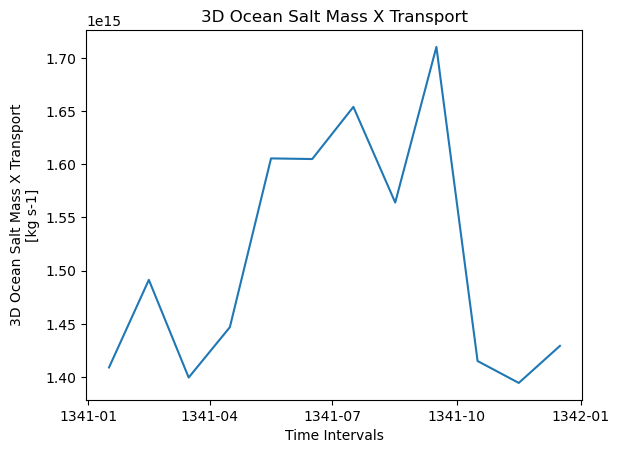

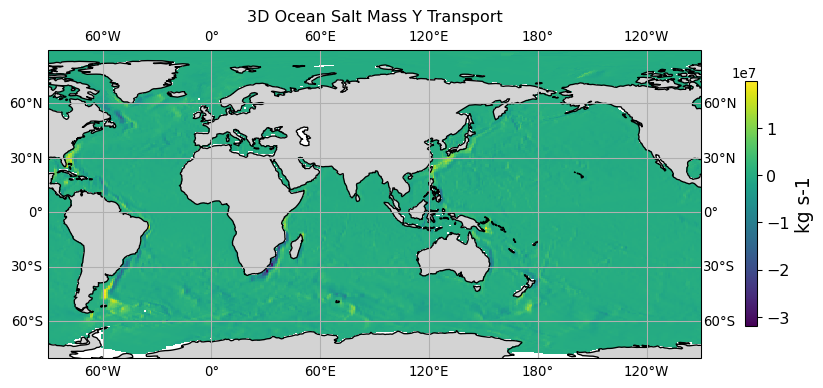

sfy: [3.31730096e+13 5.68996061e+13 5.00339712e+13 6.91470021e+13
 6.92272747e+13 7.12232285e+13 9.06430507e+13 7.68122063e+13
 5.72446522e+13 3.77043691e+13 5.20642379e+13 4.98814542e+13]


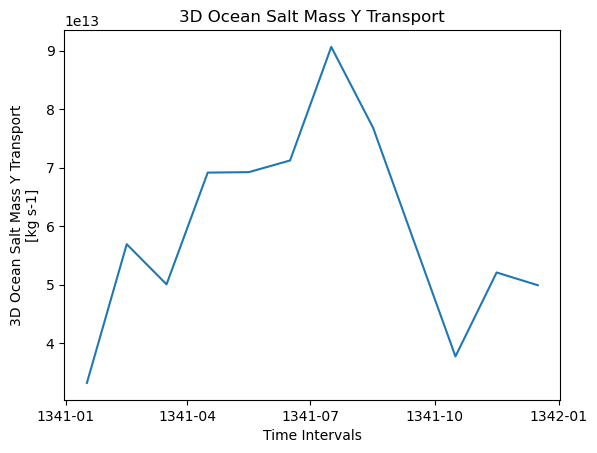

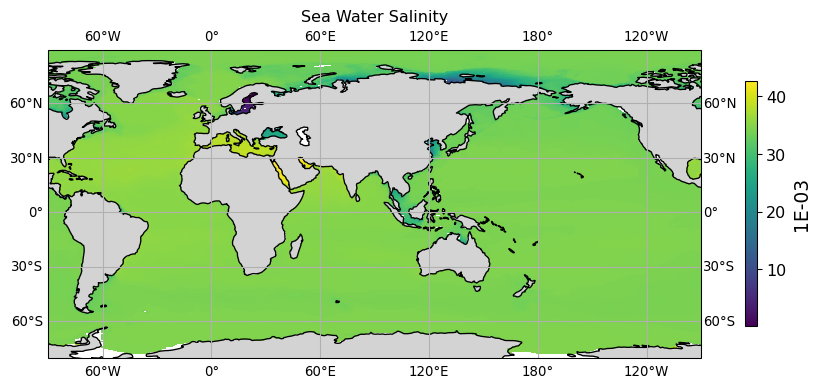

so: [1.43186537e+11 1.43006069e+11 1.43016241e+11 1.43017812e+11
 1.43007669e+11 1.42986249e+11 1.42965618e+11 1.42957148e+11
 1.42954114e+11 1.42957577e+11 1.42964975e+11 1.42980711e+11]


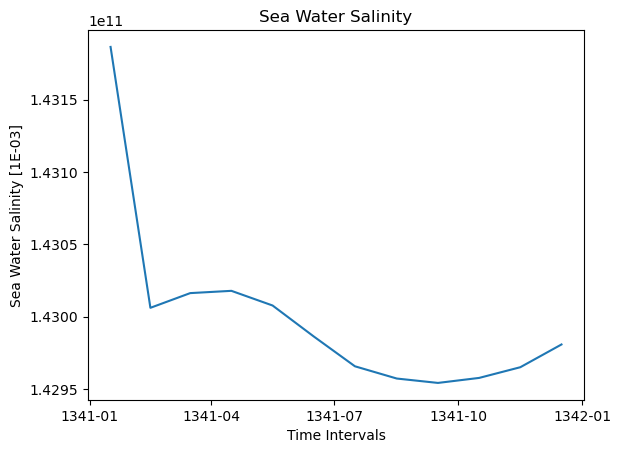

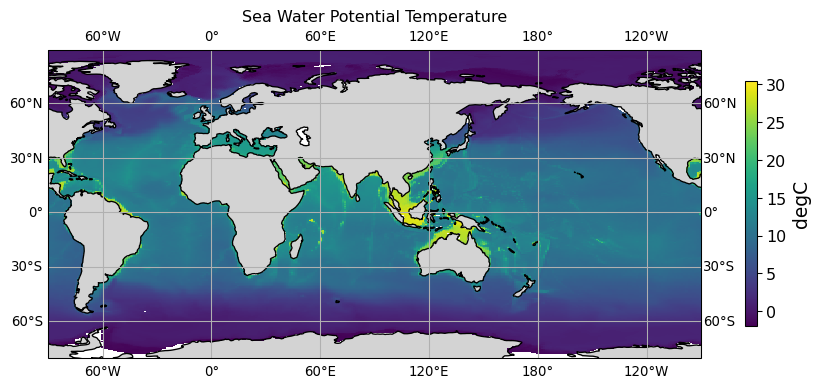

thetao: [3.68753444e+10 3.69344481e+10 3.70004763e+10 3.70444950e+10
 3.70531249e+10 3.71230732e+10 3.72058047e+10 3.72869291e+10
 3.73013761e+10 3.72039868e+10 3.70833975e+10 3.70321400e+10]


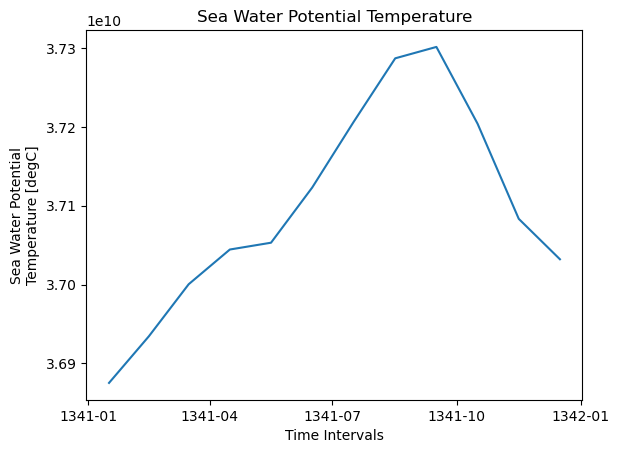

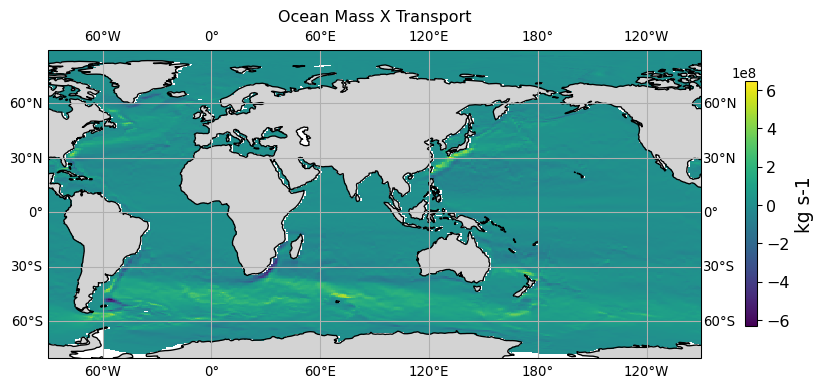

umo: [4.12866420e+16 4.36490724e+16 4.09591354e+16 4.23267847e+16
 4.68929370e+16 4.68641565e+16 4.82740577e+16 4.56931144e+16
 4.99277576e+16 4.14294867e+16 4.08769702e+16 4.18362985e+16]


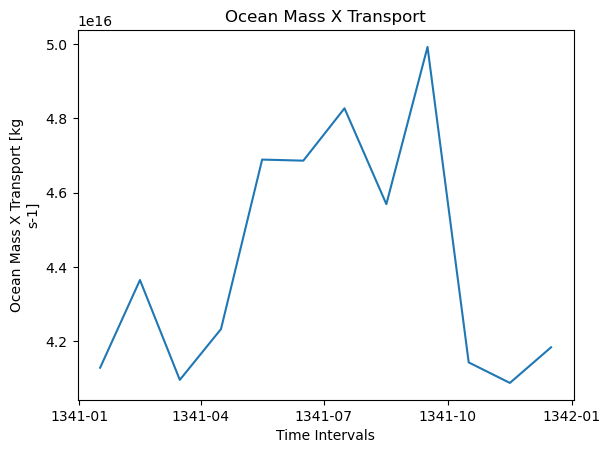

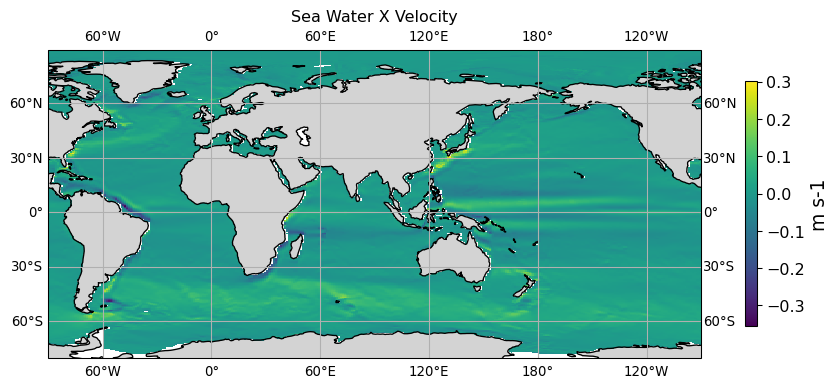

uo: [15406706.6526844  15381843.2813962  15322834.49078637 17421315.89699636
 22247282.0601158  22845786.65114897 19421471.69452506 14131865.68957449
 11492821.01924987 13450778.39757867 19981730.2819531  19062513.3632951 ]


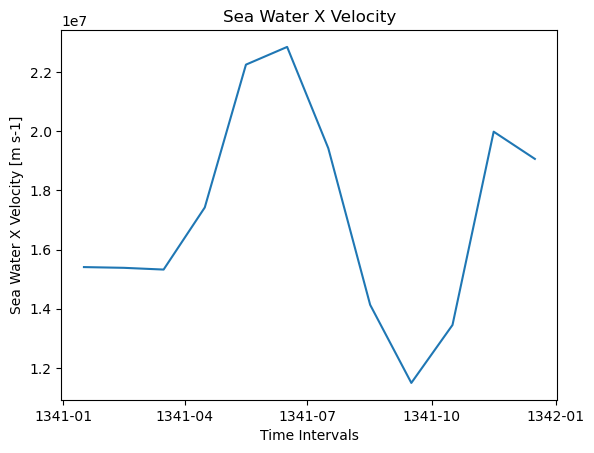

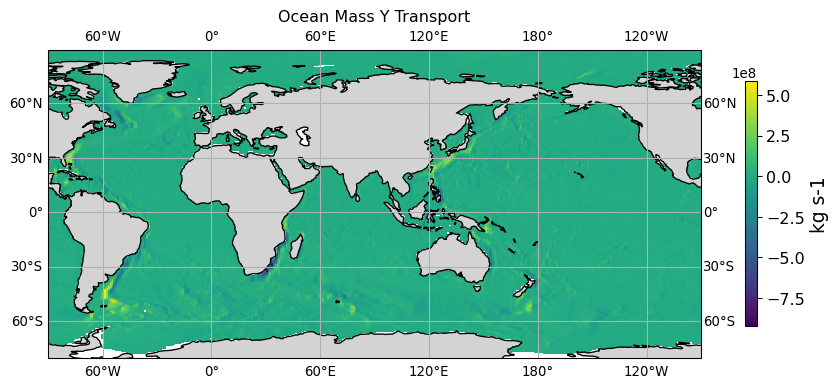

vmo: [9.36876422e+14 1.65664984e+15 1.46798249e+15 2.02252212e+15
 2.01614399e+15 2.08714725e+15 2.66865769e+15 2.25097346e+15
 1.65815008e+15 1.01049826e+15 1.46325648e+15 1.43535435e+15]


KeyboardInterrupt: 

In [7]:
# load compound names
cnames = read_compound_name()

for cname in cnames:
    var = cname.split('.')[1]
    coord = cname.split('.')[2]
    grid = 'g999'

    if coord != 'tavg-ol-hxy-sea':
        continue

    #data_file = 'masscello_tavg-ol-hxy-sea_mon_glb_g999_DUMMY-MODEL_piControl_r1i1p1f1_134101-134112.nc'
    data_file = var+'_'+coord+'_mon_glb_'+grid+'_'+model+'_'+experiment+'_'+variant+'_134101-134112.nc'

    if data_file not in os.listdir(data_path):
        continue

    with xr.open_dataset(os.path.join(data_path, data_file)) as ds:
        if var in ds:
            data = ds[var]
        else:
            continue

    data2d = data.mean(dim='lev').where(pmask == 1)

    fig, ax = plot_map2d(lon, lat, data2d.mean(dim='time'), proj='PlateCarree', norm=None)
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    plt.title(data2d.long_name)
    plt.show()

    data1d = (data2d*parea).mean(dim=['j', 'i'])
    print(f'{var}: {data1d.values}')
    fig1d = plt.figure()
    data1d.plot()
    plt.title(data1d.long_name)
    plt.show()



Text(0.5, 1.0, 'Ocean Grid-Cell Mass per Area')

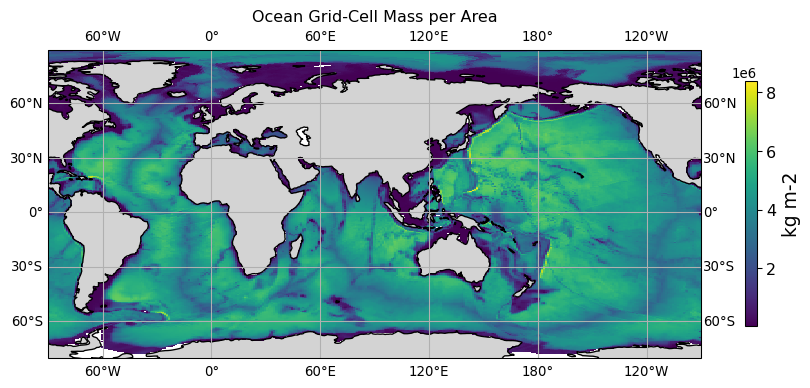

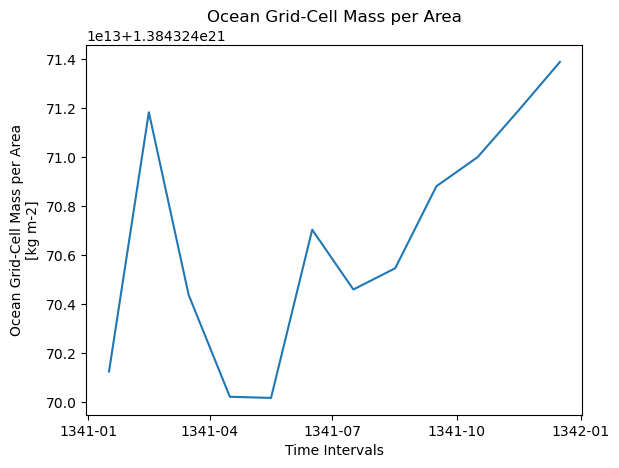